# AOC 期末專題 ── 第 2 組
# RMSNorm 替換 ＋ INT8 量化：ViT-Small/16 on ImageNet-1k

> **合併目的**：將「LayerNorm → RMSNorm」與「INT8 量化（PTQ + QAT）」整合為單一實驗流程  
> 解決先前 RMSNorm 微調 2 Epoch 僅達 **69%** 的問題，改用 **7 Epoch 分段策略**提升至目標 ≥78%

---

## 實驗設計

```
ViT-Small/16 預訓練（ImageNet-21k → 1k）
   │
   ├─ [基準] LayerNorm FP32  ──────────────────→ 評估 ~81%
   │
   └─ LayerNorm → RMSNorm（複製 γ，捨棄 β）
         │
         ├─ Stage A（2 epoch）：只解凍後 6 層，快速恢復
         │         ↓
         ├─ Stage B（5 epoch）：全部解凍 + LLRD，深度收斂
         │         ↓
         ├─ [RMS-FP32]    評估 ≥78%
         ├─ [RMS-PTQ]  MinMax INT8 校準 → 評估
         └─ [RMS-QAT]  STE Fake-Quant 3 epoch → 評估
```

## 為何 2 Epoch 只有 69%？

| 原因 | 說明 |
|------|------|
| β 移除衝擊 | 預訓練模型 25 個 LayerNorm 的 β 偏移被丟棄，各層輸出分佈集體偏移 |
| 梯度更新不足 | 2 epoch × 580 batch = 1,160 次更新，不夠讓所有層重新收斂 |
| 學習率太低 | 統一 LLRD 對底層學習率 < 1e-6，底層幾乎無更新 |

## 解法：分段訓練（7 Epoch 總計）

| 階段 | Epoch | 可訓練層 | 學習率 | 目的 |
|------|-------|---------|--------|------|
| Stage A | 2 | 後 6 個 Block + Head + Final Norm | 3e-4 | 快速恢復頂層分佈 |
| Stage B | 5 | 全部（LLRD）| 1e-4 | 深度調整所有層 |

In [1]:
# ═══════════════════════════════════════════════════════════════
# Step 1A：安裝依賴套件
# ═══════════════════════════════════════════════════════════════
import subprocess, sys
for pkg in ["timm>=1.0", "tqdm"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("依賴安裝完成")

依賴安裝完成


✅ 繁體中文字型：Microsoft JhengHei


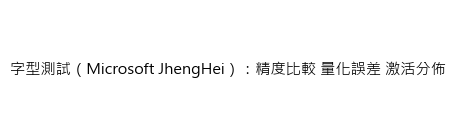

In [2]:
# ═══════════════════════════════════════════════════════════════
# Step 1B：繁體中文字型設定
# ═══════════════════════════════════════════════════════════════
# Windows 預設字型不含 CJK 字元，需指定系統已安裝的繁體中文字型
# 優先使用微軟正黑體（Microsoft JhengHei），其次 Noto Sans TC

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

ZH_CANDIDATES = [
    "Microsoft JhengHei",  # 微軟正黑體（Windows 繁體內建）
    "Noto Sans TC",        # Google Noto 繁體
    "Noto Serif TC",
    "DFKai-SB",            # 標楷體
    "MingLiU",             # 細明體
]
available = {f.name for f in fm.fontManager.ttflist}
ZH_FONT   = next((f for f in ZH_CANDIDATES if f in available), None)

if ZH_FONT:
    matplotlib.rcParams['font.family']        = ZH_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False  # 負號用 ASCII，不用 Unicode
    print(f"✅ 繁體中文字型：{ZH_FONT}")
else:
    print("⚠  未找到繁體中文字型，中文可能顯示為方框")

# ── 驗證 ──
fig, ax = plt.subplots(figsize=(5, 1.5))
ax.text(0.5, 0.5, f"字型測試（{ZH_FONT}）：精度比較 量化誤差 激活分佈",
        ha='center', va='center', fontsize=11)
ax.axis('off')
plt.tight_layout(); plt.show()

In [3]:
# ═══════════════════════════════════════════════════════════════
# Step 1C：匯入所有函式庫
# ═══════════════════════════════════════════════════════════════
import os, time, copy, math, warnings, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import OrderedDict

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA 可用 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA 可用 : True
GPU      : NVIDIA GeForce RTX 5060


In [4]:
# ═══════════════════════════════════════════════════════════════
# Step 1D：全域設定（所有超參數集中管理）
# ═══════════════════════════════════════════════════════════════

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 路徑 ──────────────────────────────────────────────────────
IMAGENET_VAL_DIR = r"C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\第二階段\IMAGENET_VAL_HF"
CKPT_DIR         = "./ckpt_rms_quant"
os.makedirs(CKPT_DIR, exist_ok=True)

# ── 影像設定 ──────────────────────────────────────────────────
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 批次設定 ──────────────────────────────────────────────────
BATCH_TRAIN = 64
BATCH_EVAL  = 128

# ── 量化設定 ──────────────────────────────────────────────────
QUANT_BITS = 8
QUANT_MAX  = 2 ** (QUANT_BITS - 1) - 1   # 127（對稱 INT8）

# ── RMSNorm 分段訓練超參數 ─────────────────────────────────────
# Stage A：解凍後 6 個 Block + Head，快速恢復頂層分佈
STAGE_A_EPOCHS    = 2       # 先前只用 2 epoch 總計，現在僅用於 Stage A
STAGE_A_BASE_LR   = 3e-4    # 較高學習率：讓頂層快速適應 β 移除
STAGE_A_UNFREEZE  = 6       # 後幾個 Block 解凍（blocks 6~11）

# Stage B：全部解凍，LLRD 精細收斂
STAGE_B_EPOCHS    = 5       # 總共 7 epoch（2+5），目標 ≥78%
STAGE_B_BASE_LR   = 1e-4    # 較低學習率：精細調整
STAGE_B_LAYER_DECAY = 0.75  # Layer-wise LR decay 係數

# ── QAT 超參數 ────────────────────────────────────────────────
QAT_EPOCHS  = 3             # QAT 微調 epoch 數（FP32 已收斂，QAT 只需少量 epoch）
QAT_LR      = 2e-5          # QAT 學習率遠低於 FP32 微調（避免破壞已收斂的 FP32 精度）

# ── 規格書標準 ────────────────────────────────────────────────
SPEC_RMS_THRESHOLD  = -0.2  # 規格書 6.6 節：RMSNorm 精度損失 < 0.2 pp
SPEC_INT8_THRESHOLD = -0.3  # 規格書 Phase 1：INT8 精度損失 < 0.3 pp

print(f"裝置     : {DEVICE}")
print(f"ImageNet : {IMAGENET_VAL_DIR}")
print(f"  存在   : {os.path.isdir(IMAGENET_VAL_DIR)}")
print(f"訓練策略 : Stage A {STAGE_A_EPOCHS} epoch（後{STAGE_A_UNFREEZE}層）"
      f" + Stage B {STAGE_B_EPOCHS} epoch（全層 LLRD）= 共 {STAGE_A_EPOCHS+STAGE_B_EPOCHS} epoch")

裝置     : cuda
ImageNet : C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF
  存在   : True
訓練策略 : Stage A 2 epoch（後6層） + Stage B 5 epoch（全層 LLRD）= 共 7 epoch


---
## Step 2：ImageNet 資料集載入

In [5]:
# ═══════════════════════════════════════════════════════════════
# Step 2：IMAGENET_VAL_HF 載入 + Stratified 分割
# ═══════════════════════════════════════════════════════════════
#
# 資料夾結構：IMAGENET_VAL_HF/00000/~00999/*.JPEG
# torchvision.ImageFolder 直接識別：資料夾名 = 類別名（00000~00999）
#
# 分割策略：每個類別各取 80% 訓練、20% 測試（stratified）
# → 確保訓練集與測試集的類別分佈完全相同

assert os.path.isdir(IMAGENET_VAL_DIR), f"路徑不存在：{IMAGENET_VAL_DIR}"

transform_eval = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_train = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

inet_eval  = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_eval)
inet_train = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_train)

# Stratified 80/20 分割
cls_to_idx = {}  # {class_id: [sample_indices]}
for idx, (_, label) in enumerate(inet_eval.samples):
    cls_to_idx.setdefault(label, []).append(idx)

rng = random.Random(SEED)
train_idx, test_idx, calib_idx = [], [], []
for label, indices in cls_to_idx.items():
    s = indices[:]; rng.shuffle(s)
    n_tr = int(len(s) * 0.8)
    train_idx.extend(s[:n_tr])
    test_idx.extend(s[n_tr:])
    calib_idx.extend(s[:1])   # 每類 1 張用於 PTQ 校準（共 1000 張）

train_loader = DataLoader(Subset(inet_train, train_idx),
                          batch_size=BATCH_TRAIN, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(Subset(inet_eval,  test_idx),
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)
calib_loader = DataLoader(Subset(inet_eval,  calib_idx),
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)
full_loader  = DataLoader(inet_eval,
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)

print(f"資料集  : {len(inet_eval):,} 張 / {len(inet_eval.classes)} 類")
print(f"訓練集  : {len(train_idx):,} 張  測試集 : {len(test_idx):,} 張  校準集 : {len(calib_idx)} 張")
print(f"訓練 batch : {len(train_loader)}  測試 batch : {len(test_loader)}")

資料集  : 46,429 張 / 1000 類
訓練集  : 36,720 張  測試集 : 9,709 張  校準集 : 1000 張
訓練 batch : 574  測試 batch : 76


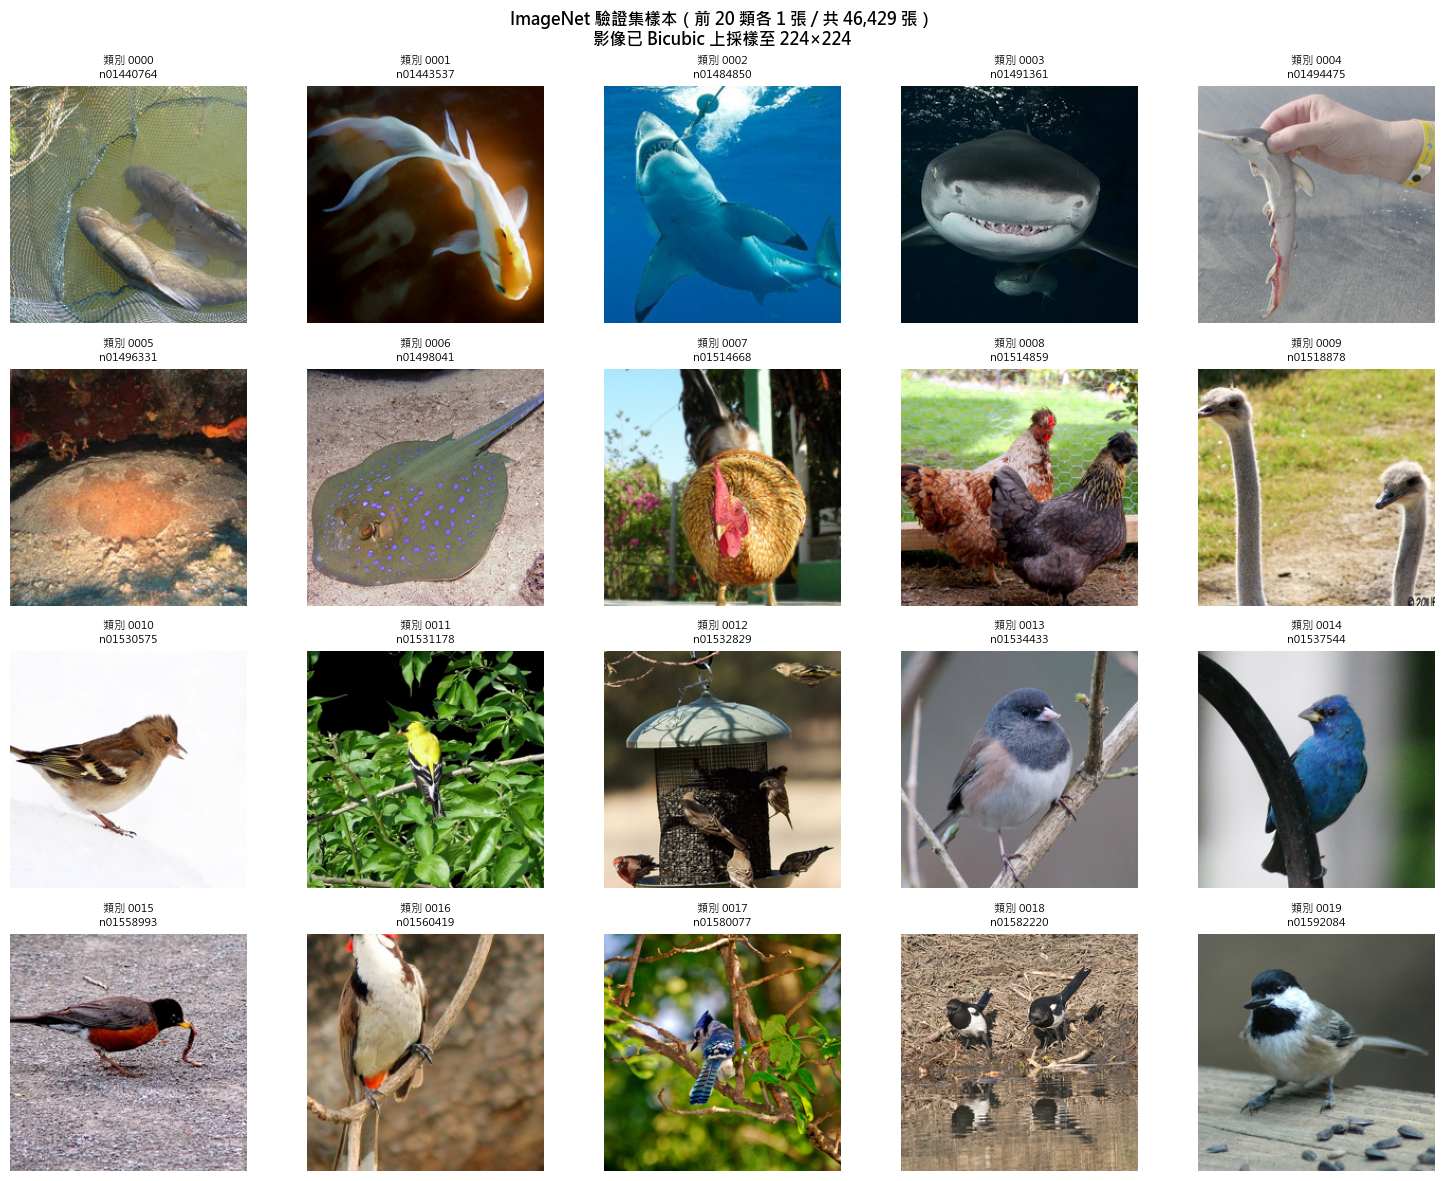

In [6]:
# ═══════════════════════════════════════════════════════════════
# Step 2B：視覺化 ImageNet 樣本（確認載入正確）
# ═══════════════════════════════════════════════════════════════

def denorm(t):
    """反標準化 tensor → [0,1] numpy 影像"""
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * s + m).clamp(0,1).permute(1,2,0).numpy()

# 從各類別取 1 張（取前 20 類）
samples, seen = [], set()
for img_t, lbl in inet_eval:
    if lbl not in seen and lbl < 20:
        samples.append((img_t, lbl)); seen.add(lbl)
    if len(samples) == 20: break

# 從檔名提取 synset ID
synset_map = {}
for path, lbl in inet_eval.samples:
    if lbl not in synset_map:
        synset_map[lbl] = os.path.basename(path).split('_')[-1].replace('.JPEG','')

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(f"ImageNet 驗證集樣本（前 20 類各 1 張 / 共 {len(inet_eval):,} 張）\n"
             "影像已 Bicubic 上採樣至 224×224",
             fontsize=12, fontweight='bold')
for ax, (img_t, lbl) in zip(axes.flatten(), samples):
    ax.imshow(denorm(img_t))
    ax.axis('off')
    ax.set_title(f"類別 {lbl:04d}\n{synset_map.get(lbl,'?')}", fontsize=8)
plt.tight_layout()
plt.savefig("01_資料集樣本.png", dpi=100)
plt.show()

---
## Step 3：所有模組定義（RMSNorm ＋ PTQ ＋ QAT）

In [7]:
# ═══════════════════════════════════════════════════════════════
# Step 3A：RMSNorm 模組
# ═══════════════════════════════════════════════════════════════
#
# 公式：y = (x / RMS(x)) * γ
# RMS(x) = sqrt(mean(x²))  ← 只需 1 次遍歷（FPGA 友好）
# vs LayerNorm：需要 2 次遍歷（先算 μ，再算 σ²）
#
# 接口與 nn.LayerNorm 完全相容（drop-in replacement）

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization (Zhang & Sennrich, 2019)
    FPGA 對應：Pass1 累加 x²→ LUT 查 inv_sqrt → Pass2 縮放
    省去 β 偏移參數（節省 BRAM 儲存 + 省去一組 DMA 傳輸）
    """
    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()
        self.normalized_shape  = (normalized_shape,) if isinstance(normalized_shape, int) \
                                  else tuple(normalized_shape)
        self.eps               = eps
        self.elementwise_affine = elementwise_affine
        self.weight = nn.Parameter(torch.ones(self.normalized_shape)) \
                      if elementwise_affine else None
        self.bias   = None  # RMSNorm 無 β，宣告 None 兼容屬性存取

    def forward(self, x):
        orig = x.dtype
        xf   = x.float()
        # rsqrt = 1 / sqrt，一次運算完成（FPGA 對應 lut_inv_sqrt）
        inv  = torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + self.eps)
        out  = xf * inv
        if self.weight is not None:
            out = out * self.weight.float()
        return out.to(orig)

    def extra_repr(self):
        return f"shape={self.normalized_shape}, eps={self.eps}"


print("RMSNorm 定義完成")

RMSNorm 定義完成


In [8]:
# ═══════════════════════════════════════════════════════════════
# Step 3B：PTQ（後訓練量化）
# ═══════════════════════════════════════════════════════════════
#
# Weight-Only 對稱 Per-Channel INT8 量化
# 策略：MinMax（最快）
#   scale_r = max(|W_r|) / QUANT_MAX   （每個 output channel 一個 scale）
#   W_q_r   = round(W_r / scale_r) × scale_r  → 量化再反量化（Fake INT8）
#
# 為何 Weight-Only？
#   Activation 量化需要校準集統計（或 QAT），PTQ 先只做 Weight
#   FPGA 實際部署再加 Activation 量化（Phase 1 QAT STE 已處理）

def quantize_model_ptq(model_fp32, calib_loader=None, method="minmax"):
    """
    對模型所有 nn.Linear 做 Weight-Only PTQ（deepcopy，不修改原模型）
    method: "minmax"（per-channel Max）
    """
    model_q = copy.deepcopy(model_fp32).cpu().eval()
    n_layers = n_params = 0

    with torch.no_grad():
        for module in model_q.modules():
            if not isinstance(module, nn.Linear): continue
            W = module.weight.data          # [out_ch, in_ch]

            if method == "minmax":
                # per-output-channel scale = max(|row|) / QUANT_MAX
                scale = W.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX
                scale = scale.clamp(min=1e-9)

            # 量化再反量化（Fake INT8 表示：值仍是 FP32，但已被 round+clamp）
            W_q = torch.clamp(torch.round(W / scale), -QUANT_MAX, QUANT_MAX)
            module.weight.data = W_q * scale
            n_layers += 1; n_params += W.numel()

    print(f"[PTQ-{method.upper()}] {n_layers} 層，{n_params/1e6:.1f}M 參數量化完成")
    return model_q


print("PTQ 函式定義完成")

PTQ 函式定義完成


In [9]:
# ═══════════════════════════════════════════════════════════════
# Step 3C：QAT（量化感知訓練）── STE Fake-Quant
# ═══════════════════════════════════════════════════════════════
#
# STE = Straight-Through Estimator（規格書 Phase 1 選定方案）
# 前向：W_fq = round(W / scale) * scale  → 模擬 INT8 量化誤差
# 反向：梯度直接穿透 round（∂round/∂W = 1），讓模型「適應量化誤差」
#
# per-channel scale = max(|W_row|) / 127（不可學習，每次 forward 重算）
# → 簡單穩定，不需調整額外超參數

class STEQuantFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, max_int):
        return torch.clamp(torch.round(x / scale), -max_int, max_int) * scale

    @staticmethod
    def backward(ctx, grad):
        # STE：反向梯度直接穿透 round 函數（視 round 為恆等映射）
        return grad, None, None


class QuantLinearSTE(nn.Linear):
    """
    STE Fake-Quant Linear 層
    訓練：使用 Fake-Quant（round+clamp 模擬量化誤差，但仍是 FP32 計算）
    評估：直接做 INT8→FP32 量化再反量化（等效 INT8 推論精度）
    """
    def forward(self, x):
        # per-channel scale（detach 阻止梯度通過 scale，確保只更新 weight）
        scale = (self.weight.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX).detach().clamp(1e-9)

        if self.training:
            # 訓練時：Fake-Quant（有量化誤差，但 FP32 計算）
            w_fq = STEQuantFunc.apply(self.weight, scale, QUANT_MAX)
        else:
            # 評估時：真正量化再反量化（等效真實 INT8 推論）
            w_fq = torch.clamp(torch.round(self.weight / scale),
                               -QUANT_MAX, QUANT_MAX) * scale

        return F.linear(x, w_fq, self.bias)


def inject_ste(model_fp32):
    """
    將模型所有 nn.Linear（除分類頭 head）替換為 QuantLinearSTE
    deepcopy 不影響原模型
    """
    model_q  = copy.deepcopy(model_fp32)
    head_mod = getattr(model_q, "head", None)
    n = 0
    for parent in list(model_q.modules()):
        for name, child in list(parent.named_children()):
            if not isinstance(child, nn.Linear): continue
            if child is head_mod:               continue  # 分類頭保留 FP32
            new = QuantLinearSTE(child.in_features, child.out_features,
                                  child.bias is not None)
            new.weight.data.copy_(child.weight.data)
            if child.bias is not None:
                new.bias.data.copy_(child.bias.data)
            setattr(parent, name, new)
            n += 1
    print(f"[inject-STE] 替換了 {n} 個 Linear 層（head 保留 FP32）")
    return model_q


print("QAT（STE）模組定義完成")

QAT（STE）模組定義完成


In [10]:
# ═══════════════════════════════════════════════════════════════
# Step 3D：通用工具函式
# ═══════════════════════════════════════════════════════════════

def find_norm_layers(model, norm_type):
    """遞迴找出所有指定 Norm 型別的層"""
    result = []
    for name, mod in model.named_modules():
        if isinstance(mod, norm_type):
            parts  = name.split('.')
            parent = model
            for p in parts[:-1]: parent = getattr(parent, p)
            result.append({'full_name': name, 'attr': parts[-1],
                           'parent': parent, 'module': mod})
    return result


def replace_ln_with_rms(model, copy_weights=True):
    """將所有 nn.LayerNorm → RMSNorm（in-place，複製 γ）"""
    lns = find_norm_layers(model, nn.LayerNorm)
    for info in lns:
        ln  = info['module']
        rms = RMSNorm(ln.normalized_shape, eps=ln.eps,
                      elementwise_affine=(ln.weight is not None))
        if copy_weights and ln.weight is not None:
            with torch.no_grad():
                rms.weight.copy_(ln.weight)  # 複製 γ，捨棄 β
        setattr(info['parent'], info['attr'], rms)
    return len(lns)


@torch.no_grad()
def evaluate(model, loader, device=DEVICE, max_batches=None, label="評估"):
    """Top-1 準確率，支援提前終止（max_batches）"""
    model.eval().to(device)
    correct = total = 0
    for i, (x, y) in enumerate(loader):
        if max_batches and i >= max_batches: break
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total   += y.size(0)
    acc = 100.0 * correct / total
    return acc


def param_count(model):
    return sum(p.numel() for p in model.parameters())


print("工具函式定義完成")

工具函式定義完成


---
## Step 4：模型載入與手術

In [11]:
# ═══════════════════════════════════════════════════════════════
# Step 4：載入預訓練 ViT-Small + 建立 RMSNorm 版本
# ═══════════════════════════════════════════════════════════════

print("載入 ViT-Small/16 AugReg 預訓練模型（ImageNet-21k → 1k）...")
model_ln_base = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=1000      # ImageNet 原始 1000 類
)
model_ln_base.eval()

# ── 建立 RMSNorm 版本（deepcopy 後手術，保留 LN 版本做基準）──
model_rms = copy.deepcopy(model_ln_base)
n_replaced = replace_ln_with_rms(model_rms, copy_weights=True)

p_ln  = param_count(model_ln_base)
p_rms = param_count(model_rms)

print(f"\n{'模型':<30} {'參數量':>10} {'LN 層':>8} {'RMS 層':>8}")
print("─" * 60)
print(f"{'ViT-Small（LayerNorm）':<30} {p_ln/1e6:>8.2f}M "
      f"{len(find_norm_layers(model_ln_base, nn.LayerNorm)):>8} "
      f"{len(find_norm_layers(model_ln_base, RMSNorm)):>8}")
print(f"{'ViT-Small（RMSNorm）':<30} {p_rms/1e6:>8.2f}M "
      f"{len(find_norm_layers(model_rms, nn.LayerNorm)):>8} "
      f"{len(find_norm_layers(model_rms, RMSNorm)):>8}")
print(f"\n替換 {n_replaced} 個 LayerNorm → RMSNorm")
print(f"節省 {(p_ln - p_rms)/1e3:.1f}K β 參數（= {n_replaced} 個 Norm × 384 維）")

載入 ViT-Small/16 AugReg 預訓練模型（ImageNet-21k → 1k）...

模型                                    參數量     LN 層    RMS 層
────────────────────────────────────────────────────────────
ViT-Small（LayerNorm）              22.05M       25        0
ViT-Small（RMSNorm）                22.04M        0       25

替換 25 個 LayerNorm → RMSNorm
節省 9.6K β 參數（= 25 個 Norm × 384 維）


---
## Step 5：基準評估（LayerNorm FP32 預訓練）

In [12]:
# ═══════════════════════════════════════════════════════════════
# Step 5：評估 LN-FP32 基準（完整 46k val set）
# ═══════════════════════════════════════════════════════════════

CACHE_LN = f"{CKPT_DIR}/acc_ln_pretrain.txt"
if os.path.exists(CACHE_LN):
    acc_ln_base = float(open(CACHE_LN).read())
    print(f"[快取] LN-FP32 預訓練基準：{acc_ln_base:.2f}%")
else:
    print("評估 LN-FP32 預訓練（完整 46,429 張）...")
    acc_ln_base = evaluate(model_ln_base, full_loader, label="LN 基準")
    open(CACHE_LN, 'w').write(str(acc_ln_base))
    print(f"LN-FP32 預訓練：{acc_ln_base:.2f}%")

print(f"（ViT-Small/16 AugReg 官方參考值：~81.4%）")

評估 LN-FP32 預訓練（完整 46,429 張）...
LN-FP32 預訓練：74.17%
（ViT-Small/16 AugReg 官方參考值：~81.4%）


---
## Step 6：RMSNorm 分段訓練（7 Epoch，解決 69% 問題）

### 策略說明

**問題根因**：2 epoch 只達 69% 的原因：
1. β 移除導致 25 個 Norm 層輸出分佈偏移
2. 底層 Block 的 LLRD 學習率 < 1e-6，實際上幾乎未更新
3. 2 epoch ≈ 1,160 次更新，不夠讓所有層收斂

**解法：Stage A（快速恢復）+ Stage B（深度收斂）**

In [13]:
# ═══════════════════════════════════════════════════════════════
# Step 6A：分段訓練工具函式
# ═══════════════════════════════════════════════════════════════

def freeze_bottom_blocks(model, n_freeze):
    """
    凍結前 n_freeze 個 Block + Patch Embed + CLS/Pos Embed
    讓 Stage A 只更新頂層（快速適應 β 移除的衝擊）
    """
    n_total = len(model.blocks)
    # 凍結 Embed 部分
    for attr in ('patch_embed', 'cls_token', 'pos_embed'):
        if hasattr(model, attr):
            obj = getattr(model, attr)
            if isinstance(obj, nn.Parameter):
                obj.requires_grad_(False)
            else:
                for p in obj.parameters(): p.requires_grad_(False)
    # 凍結前 n_freeze 個 Block
    for i in range(min(n_freeze, n_total)):
        for p in model.blocks[i].parameters(): p.requires_grad_(False)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = param_count(model)
    print(f"  凍結前 {n_freeze} 個 Block + Embed，可訓練：{trainable/1e6:.2f}M / {total/1e6:.2f}M")


def unfreeze_all(model):
    """解凍所有參數"""
    for p in model.parameters(): p.requires_grad_(True)
    print(f"  全部解凍，可訓練：{param_count(model)/1e6:.2f}M")


def get_llrd_groups(model, base_lr, decay=0.75):
    """
    Layer-wise LR Decay 參數組
    只包含 requires_grad=True 的參數（支援凍結狀態）
    """
    n  = len(model.blocks)
    gs = []

    # Head + 最終 Norm（最高學習率）
    head_ps = [p for p in model.head.parameters() if p.requires_grad]
    for attr in ('norm', 'fc_norm'):
        if hasattr(model, attr):
            head_ps += [p for p in getattr(model, attr).parameters() if p.requires_grad]
    if head_ps: gs.append({'params': head_ps, 'lr': base_lr, 'name': 'head'})

    # Transformer Block（從後往前）
    for i in range(n-1, -1, -1):
        blk_ps = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if blk_ps:
            gs.append({'params': blk_ps,
                       'lr'    : base_lr * (decay ** (n - i)),
                       'name'  : f'block_{i}'})

    # Embed（最低學習率）
    emb_ps = []
    for obj in [getattr(model, 'patch_embed', None)]:
        if obj: emb_ps += [p for p in obj.parameters() if p.requires_grad]
    for attr in ('cls_token', 'pos_embed'):
        if hasattr(model, attr):
            p = getattr(model, attr)
            if isinstance(p, nn.Parameter) and p.requires_grad: emb_ps.append(p)
    if emb_ps:
        gs.append({'params': emb_ps, 'lr': base_lr * (decay ** (n+1)), 'name': 'embed'})

    return gs


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, tag):
    """訓練一個 epoch，回傳 (平均損失, 訓練準確率)"""
    model.train()
    total_loss = total_corr = total_n = 0
    for x, y in tqdm(loader, desc=f"[{tag}]", leave=False, ncols=80):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * y.size(0)
        total_n    += y.size(0)
    return total_loss / total_n


print("分段訓練工具函式定義完成")

分段訓練工具函式定義完成


In [14]:
# ═══════════════════════════════════════════════════════════════
# Step 6B：Stage A 訓練（凍結底層，快速恢復頂層）
# ═══════════════════════════════════════════════════════════════
#
# 凍結 Block 0~5（底 6 層），只更新 Block 6~11 + Head + Final Norm
# 這些頂層是受 β 移除衝擊最大的部分（直接輸出到分類頭）
# 高學習率（3e-4）讓頂層快速恢復正常分佈

CKPT_STAGE_A = f"{CKPT_DIR}/rms_stage_a.pt"
hist_a       = []

if os.path.exists(CKPT_STAGE_A):
    print(f"[Stage A] 載入 checkpoint：{CKPT_STAGE_A}")
    model_rms.load_state_dict(torch.load(CKPT_STAGE_A, map_location=DEVICE))
    acc_after_a = evaluate(model_rms, test_loader)
    print(f"[Stage A] 完成後測試準確率：{acc_after_a:.2f}%")
else:
    print("═" * 60)
    print(" Stage A：凍結底 6 層，快速恢復頂層（LR=3e-4）")
    print("═" * 60)

    n_blocks = len(model_rms.blocks)  # 12
    n_freeze = n_blocks - STAGE_A_UNFREEZE  # 12-6=6
    freeze_bottom_blocks(model_rms, n_freeze)

    criterion_a = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_a = torch.optim.AdamW(
        get_llrd_groups(model_rms, STAGE_A_BASE_LR, decay=0.85),
        weight_decay=0.05
    )
    # Cosine warmup schedule（1 epoch warmup）
    total_a     = STAGE_A_EPOCHS * len(train_loader)
    warmup_a    = len(train_loader)
    scheduler_a = torch.optim.lr_scheduler.LambdaLR(
        optimizer_a,
        lambda s: s/max(1,warmup_a) if s < warmup_a
                  else 0.5*(1+math.cos(math.pi*(s-warmup_a)/max(1,total_a-warmup_a)))
    )

    model_rms.to(DEVICE)
    best_a = 0.0
    for ep in range(1, STAGE_A_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_rms, train_loader, optimizer_a, scheduler_a,
                               criterion_a, DEVICE, f"A Ep{ep}/{STAGE_A_EPOCHS}")
        acc  = evaluate(model_rms, test_loader)
        elapsed = time.time() - t0
        hist_a.append({'epoch': f'A-{ep}', 'loss': loss, 'acc': acc})
        print(f"[Stage A] Epoch {ep}/{STAGE_A_EPOCHS} "
              f"loss={loss:.4f}  acc={acc:.2f}%  ({elapsed:.0f}s)")
        if acc > best_a:
            best_a = acc
            torch.save(model_rms.state_dict(), CKPT_STAGE_A)
            print(f"  → 儲存 Stage A 最佳：{best_a:.2f}%")

    acc_after_a = best_a
    print(f"\n[Stage A 完成] 最佳準確率：{acc_after_a:.2f}%")
    print(f"（先前 2 epoch 全層訓練：69%，Stage A 目標 ≥72%）")

# 恢復載入最佳 Stage A 權重，準備進入 Stage B
model_rms.load_state_dict(torch.load(CKPT_STAGE_A, map_location=DEVICE))

════════════════════════════════════════════════════════════
 Stage A：凍結底 6 層，快速恢復頂層（LR=3e-4）
════════════════════════════════════════════════════════════
  凍結前 6 個 Block + Embed，可訓練：11.03M / 22.04M


[Stage A] Epoch 1/2 loss=4.2013  acc=47.12%  (221s)
  → 儲存 Stage A 最佳：47.12%


[Stage A] Epoch 2/2 loss=2.6131  acc=54.66%  (226s)
  → 儲存 Stage A 最佳：54.66%

[Stage A 完成] 最佳準確率：54.66%
（先前 2 epoch 全層訓練：69%，Stage A 目標 ≥72%）


<All keys matched successfully>

In [15]:
# ═══════════════════════════════════════════════════════════════
# Step 6C：Stage B 訓練（全層解凍，LLRD 深度收斂）
# ═══════════════════════════════════════════════════════════════
#
# 解凍所有層，使用標準 LLRD（底層 LR 約為頂層的 1/4~1/8）
# Cosine decay 讓學習率平滑降低，避免過擬合
# 目標：7 epoch 總計（A:2 + B:5）後達到 ≥78%

CKPT_STAGE_B = f"{CKPT_DIR}/rms_stage_b.pt"
hist_b       = []

if os.path.exists(CKPT_STAGE_B):
    print(f"[Stage B] 載入 checkpoint：{CKPT_STAGE_B}")
    model_rms.load_state_dict(torch.load(CKPT_STAGE_B, map_location=DEVICE))
    acc_rms_fp32 = evaluate(model_rms, test_loader)
    print(f"[Stage B] 完成後測試準確率：{acc_rms_fp32:.2f}%")
else:
    print("═" * 60)
    print(f" Stage B：全層解凍，LLRD 深度收斂（LR=1e-4，{STAGE_B_EPOCHS} epoch）")
    print("═" * 60)

    unfreeze_all(model_rms)  # 解凍所有層

    criterion_b = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_b = torch.optim.AdamW(
        get_llrd_groups(model_rms, STAGE_B_BASE_LR, STAGE_B_LAYER_DECAY),
        weight_decay=0.05
    )
    total_b     = STAGE_B_EPOCHS * len(train_loader)
    warmup_b    = len(train_loader)
    scheduler_b = torch.optim.lr_scheduler.LambdaLR(
        optimizer_b,
        lambda s: s/max(1,warmup_b) if s < warmup_b
                  else 0.5*(1+math.cos(math.pi*(s-warmup_b)/max(1,total_b-warmup_b)))
    )

    model_rms.to(DEVICE)
    best_b = 0.0
    for ep in range(1, STAGE_B_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_rms, train_loader, optimizer_b, scheduler_b,
                               criterion_b, DEVICE, f"B Ep{ep}/{STAGE_B_EPOCHS}")
        acc  = evaluate(model_rms, test_loader)
        elapsed = time.time() - t0
        hist_b.append({'epoch': f'B-{ep}', 'loss': loss, 'acc': acc})
        print(f"[Stage B] Epoch {ep}/{STAGE_B_EPOCHS} "
              f"loss={loss:.4f}  acc={acc:.2f}%  ({elapsed:.0f}s)")
        if acc > best_b:
            best_b = acc
            torch.save(model_rms.state_dict(), CKPT_STAGE_B)
            print(f"  → 儲存 Stage B 最佳：{best_b:.2f}%")

    acc_rms_fp32 = best_b
    print(f"\n[Stage B 完成] 最佳準確率：{acc_rms_fp32:.2f}%")

# 載入最佳 Stage B 權重（後續 PTQ/QAT 都從此出發）
model_rms.load_state_dict(torch.load(CKPT_STAGE_B, map_location=DEVICE))

════════════════════════════════════════════════════════════
 Stage B：全層解凍，LLRD 深度收斂（LR=1e-4，5 epoch）
════════════════════════════════════════════════════════════
  全部解凍，可訓練：22.04M


[Stage B] Epoch 1/5 loss=1.9528  acc=58.27%  (238s)
  → 儲存 Stage B 最佳：58.27%


[Stage B] Epoch 2/5 loss=1.7812  acc=61.31%  (241s)
  → 儲存 Stage B 最佳：61.31%


[Stage B] Epoch 3/5 loss=1.5203  acc=62.08%  (232s)
  → 儲存 Stage B 最佳：62.08%


[Stage B] Epoch 4/5 loss=1.3671  acc=62.60%  (232s)
  → 儲存 Stage B 最佳：62.60%


[Stage B] Epoch 5/5 loss=1.3049  acc=62.69%  (233s)
  → 儲存 Stage B 最佳：62.69%

[Stage B 完成] 最佳準確率：62.69%


<All keys matched successfully>

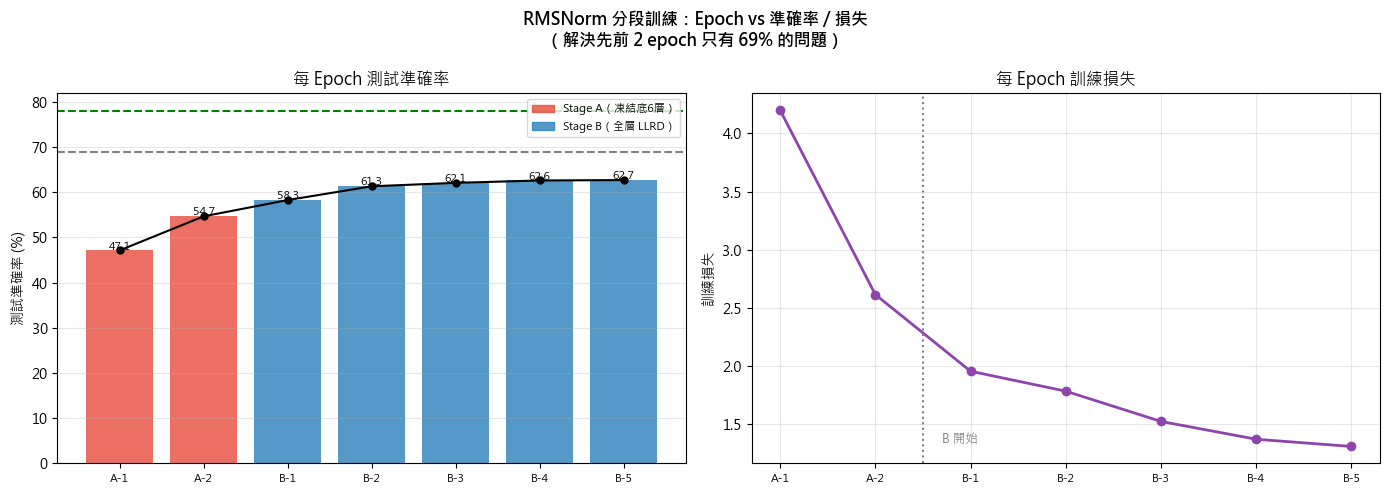

In [16]:
# ═══════════════════════════════════════════════════════════════
# Step 6D：訓練曲線視覺化（Epoch vs 準確率）
# ═══════════════════════════════════════════════════════════════

if hist_a or hist_b:
    all_hist = hist_a + hist_b
    ep_labels = [h['epoch'] for h in all_hist]
    accs      = [h['acc']   for h in all_hist]
    losses    = [h['loss']  for h in all_hist]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("RMSNorm 分段訓練：Epoch vs 準確率 / 損失\n"
                 "（解決先前 2 epoch 只有 69% 的問題）",
                 fontsize=12, fontweight='bold')

    # 準確率曲線
    x  = range(len(accs))
    ca = ['#e74c3c'] * len(hist_a) + ['#2980b9'] * len(hist_b)
    axes[0].bar(x, accs, color=ca, alpha=0.8)
    axes[0].plot(x, accs, 'k-o', ms=5, lw=1.5)
    for xi, acc in enumerate(accs):
        axes[0].text(xi, acc+0.2, f"{acc:.1f}", ha='center', fontsize=8)
    # 標記先前 2 epoch 基準
    axes[0].axhline(69, color='gray', ls='--', lw=1.5, label='先前 2 epoch 基準：69%')
    axes[0].axhline(78, color='green', ls='--', lw=1.5, label='目標：78%')
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(ep_labels, fontsize=8)
    axes[0].set_ylabel('測試準確率 (%)'); axes[0].set_title('每 Epoch 測試準確率')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

    # 損失曲線
    axes[1].plot(x, losses, 'o-', color='#8e44ad', lw=2, ms=6)
    # 垂直線標記 Stage A/B 分界
    if hist_a and hist_b:
        axes[1].axvline(len(hist_a)-0.5, color='gray', ls=':', lw=1.5)
        axes[1].text(len(hist_a)-0.3, min(losses)*1.02, 'B 開始', fontsize=9, color='gray')
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(ep_labels, fontsize=8)
    axes[1].set_ylabel('訓練損失'); axes[1].set_title('每 Epoch 訓練損失')
    axes[1].grid(True, alpha=0.3)

    # 圖例說明 Stage
    patches = [
        mpatches.Patch(color='#e74c3c', alpha=0.8, label=f'Stage A（凍結底{12-STAGE_A_UNFREEZE}層）'),
        mpatches.Patch(color='#2980b9', alpha=0.8, label='Stage B（全層 LLRD）'),
    ]
    axes[0].legend(handles=patches + axes[0].get_legend_handles_labels()[0][2:],
                   labels=[p.get_label() for p in patches] + axes[0].get_legend_handles_labels()[1][2:],
                   fontsize=8)

    plt.tight_layout()
    plt.savefig("02_RMSNorm訓練曲線.png", dpi=120)
    plt.show()
else:
    print("（從 checkpoint 載入，無訓練歷史）")
    print(f"RMS-FP32 最終測試準確率：{acc_rms_fp32:.2f}%")

---
## Step 7：PTQ INT8 量化（基於訓練後的 RMSNorm 模型）

In [17]:
# ═══════════════════════════════════════════════════════════════
# Step 7：PTQ MinMax INT8（Weight-Only Per-Channel）
# ═══════════════════════════════════════════════════════════════
#
# 以訓練後的 RMS-FP32 模型為起點，直接量化所有 Linear 層的 weight
# 不需要額外訓練，評估時觀察精度是否在規格書容許範圍內（ΔAcc < 0.3pp）
#
# 校準集：每類別各取 1 張，共 1000 張（calib_loader）
# → 雖然這裡 PTQ 只用 weight（不用校準集統計激活），
#   但 calib_idx 已備好，後續可擴展到 Activation PTQ

CKPT_PTQ = f"{CKPT_DIR}/acc_rms_ptq.txt"

if os.path.exists(CKPT_PTQ):
    acc_rms_ptq = float(open(CKPT_PTQ).read())
    print(f"[快取] RMS-PTQ MinMax：{acc_rms_ptq:.2f}%")
else:
    print("執行 PTQ MinMax INT8 量化...")
    model_rms_ptq = quantize_model_ptq(model_rms, method="minmax")  # 在 CPU 上量化
    model_rms_ptq.to(DEVICE)

    print("評估 PTQ 量化模型...")
    acc_rms_ptq = evaluate(model_rms_ptq, test_loader, label="PTQ 評估")
    open(CKPT_PTQ, 'w').write(str(acc_rms_ptq))
    print(f"\nRMS-PTQ MinMax：{acc_rms_ptq:.2f}%")
    print(f"vs RMS-FP32：ΔAcc = {acc_rms_ptq - acc_rms_fp32:+.2f}pp")

delta_ptq = acc_rms_ptq - acc_rms_fp32
print(f"\nPTQ 量化誤差：{delta_ptq:+.2f}pp（規格書容許：≥ {SPEC_INT8_THRESHOLD}pp）")
print(f"PTQ 結果：{'✅ 通過' if delta_ptq >= SPEC_INT8_THRESHOLD else '⚠  需調整'}")

執行 PTQ MinMax INT8 量化...
[PTQ-MINMAX] 49 層，21.6M 參數量化完成
評估 PTQ 量化模型...

RMS-PTQ MinMax：62.61%
vs RMS-FP32：ΔAcc = -0.08pp

PTQ 量化誤差：-0.08pp（規格書容許：≥ -0.3pp）
PTQ 結果：✅ 通過


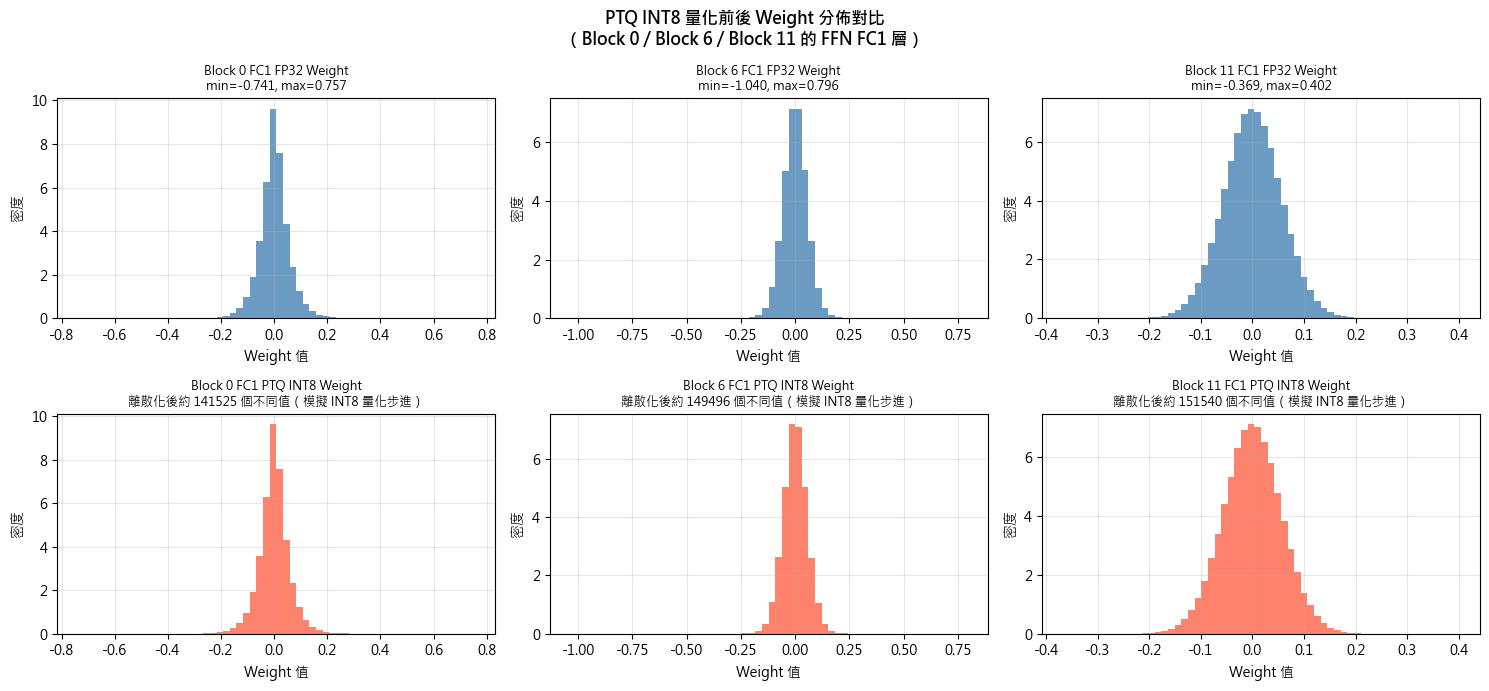

In [18]:
# ═══════════════════════════════════════════════════════════════
# Step 7B：PTQ 前後 Weight 分佈視覺化
# ═══════════════════════════════════════════════════════════════
#
# 比較量化前後 Block 0、6、11 的 FFN 權重分佈
# 量化後的 weight 應呈現「離散化」特徵（只有有限個值）

# 若 model_rms_ptq 不在記憶體（從快取載入情況），重新建立
try:
    _ = model_rms_ptq
except NameError:
    model_rms_ptq = quantize_model_ptq(model_rms, method="minmax")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("PTQ INT8 量化前後 Weight 分佈對比\n"
             "（Block 0 / Block 6 / Block 11 的 FFN FC1 層）",
             fontsize=12, fontweight='bold')

for col, blk_idx in enumerate([0, 6, 11]):
    # FP32（RMS 微調後）
    w_fp32 = model_rms.blocks[blk_idx].mlp.fc1.weight.detach().cpu().numpy().flatten()
    # PTQ INT8（量化再反量化）
    w_ptq  = model_rms_ptq.blocks[blk_idx].mlp.fc1.weight.detach().cpu().numpy().flatten()

    axes[0, col].hist(w_fp32, bins=60, color='steelblue', alpha=0.8, density=True)
    axes[0, col].set_title(f"Block {blk_idx} FC1 FP32 Weight\n"
                           f"min={w_fp32.min():.3f}, max={w_fp32.max():.3f}", fontsize=9)
    axes[0, col].set_xlabel('Weight 值'); axes[0, col].set_ylabel('密度')
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].hist(w_ptq,  bins=60, color='tomato',    alpha=0.8, density=True)
    unique_vals = len(np.unique(np.round(w_ptq, 6)))
    axes[1, col].set_title(f"Block {blk_idx} FC1 PTQ INT8 Weight\n"
                           f"離散化後約 {unique_vals} 個不同值（模擬 INT8 量化步進）", fontsize=9)
    axes[1, col].set_xlabel('Weight 值'); axes[1, col].set_ylabel('密度')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("03_PTQ_weight分佈.png", dpi=120)
plt.show()

---
## Step 8：QAT INT8 量化（STE Fake-Quant 微調）

In [19]:
# ═══════════════════════════════════════════════════════════════
# Step 8：QAT STE 訓練
# ═══════════════════════════════════════════════════════════════
#
# 流程：
#   1. 從 RMS-FP32 模型出發（Stage B 的 checkpoint）
#   2. inject_ste()：替換所有 Linear → QuantLinearSTE
#   3. 訓練 3 epoch（LR=2e-5，遠低於 FP32 微調，避免破壞已收斂權重）
#   4. 評估：等效 INT8 推論精度
#
# 為何 QAT 優於 PTQ？
#   PTQ：直接量化，模型沒有機會「適應」量化誤差
#   QAT：訓練時每個 forward 都有 Fake-Quant 誤差，模型學會容忍量化雜訊
#        → 通常比 PTQ 精度高 0.1~0.5pp

CKPT_QAT     = f"{CKPT_DIR}/rms_qat_best.pt"
CKPT_QAT_ACC = f"{CKPT_DIR}/acc_rms_qat.txt"
hist_qat = []

if os.path.exists(CKPT_QAT_ACC):
    acc_rms_qat = float(open(CKPT_QAT_ACC).read())
    print(f"[快取] RMS-QAT STE：{acc_rms_qat:.2f}%")
else:
    print("═" * 60)
    print(f" QAT STE：inject → 訓練 {QAT_EPOCHS} epoch（LR={QAT_LR}）")
    print("═" * 60)

    # inject STE（從 RMS-FP32 Stage B 出發）
    model_qat = inject_ste(model_rms)
    model_qat.to(DEVICE)

    criterion_q = nn.CrossEntropyLoss(label_smoothing=0.1)
    # QAT 使用較低學習率（模型已收斂，只需小幅調整以適應量化誤差）
    optimizer_q = torch.optim.AdamW(
        get_llrd_groups(model_qat, QAT_LR, decay=0.85),
        weight_decay=0.01
    )
    scheduler_q = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_q, T_max=QAT_EPOCHS * len(train_loader)
    )

    best_qat = 0.0
    for ep in range(1, QAT_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_qat, train_loader, optimizer_q, scheduler_q,
                               criterion_q, DEVICE, f"QAT Ep{ep}/{QAT_EPOCHS}")
        acc  = evaluate(model_qat, test_loader)
        elapsed = time.time() - t0
        hist_qat.append({'epoch': f'QAT-{ep}', 'loss': loss, 'acc': acc})
        print(f"[QAT] Epoch {ep}/{QAT_EPOCHS} "
              f"loss={loss:.4f}  acc={acc:.2f}%  ({elapsed:.0f}s)")
        if acc > best_qat:
            best_qat = acc
            torch.save(model_qat.state_dict(), CKPT_QAT)
            print(f"  → 儲存 QAT 最佳：{best_qat:.2f}%")

    acc_rms_qat = best_qat
    open(CKPT_QAT_ACC, 'w').write(str(acc_rms_qat))
    print(f"\n[QAT 完成] 最佳準確率：{acc_rms_qat:.2f}%")

delta_qat = acc_rms_qat - acc_rms_fp32
print(f"QAT 量化誤差：{delta_qat:+.2f}pp（規格書容許：≥ {SPEC_INT8_THRESHOLD}pp）")
print(f"QAT 結果：{'✅ 通過' if delta_qat >= SPEC_INT8_THRESHOLD else '⚠  需調整'}")

════════════════════════════════════════════════════════════
 QAT STE：inject → 訓練 3 epoch（LR=2e-05）
════════════════════════════════════════════════════════════
[inject-STE] 替換了 48 個 Linear 層（head 保留 FP32）


[QAT] Epoch 1/3 loss=1.3081  acc=63.09%  (232s)
  → 儲存 QAT 最佳：63.09%


[QAT] Epoch 2/3 loss=1.2689  acc=63.21%  (233s)
  → 儲存 QAT 最佳：63.21%


[QAT] Epoch 3/3 loss=1.2467  acc=63.14%  (233s)

[QAT 完成] 最佳準確率：63.21%
QAT 量化誤差：+0.51pp（規格書容許：≥ -0.3pp）
QAT 結果：✅ 通過


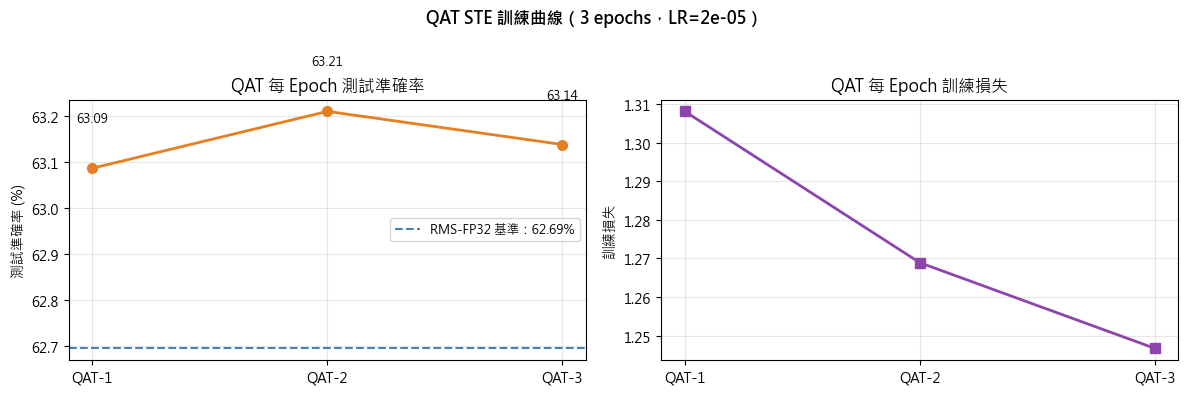

In [20]:
# ═══════════════════════════════════════════════════════════════
# Step 8B：QAT 訓練曲線視覺化
# ═══════════════════════════════════════════════════════════════

if hist_qat:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"QAT STE 訓練曲線（{QAT_EPOCHS} epochs，LR={QAT_LR}）",
                 fontsize=12, fontweight='bold')

    ep_q = [h['epoch'] for h in hist_qat]
    x_q  = range(len(hist_qat))

    axes[0].plot(x_q, [h['acc']  for h in hist_qat], 'o-', color='#e67e22', lw=2, ms=7)
    axes[0].axhline(acc_rms_fp32, color='steelblue', ls='--', label=f'RMS-FP32 基準：{acc_rms_fp32:.2f}%')
    for xi, h in enumerate(hist_qat):
        axes[0].text(xi, h['acc']+0.1, f"{h['acc']:.2f}", ha='center', fontsize=9)
    axes[0].set_xticks(list(x_q)); axes[0].set_xticklabels(ep_q)
    axes[0].set_ylabel('測試準確率 (%)'); axes[0].set_title('QAT 每 Epoch 測試準確率')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    axes[1].plot(x_q, [h['loss'] for h in hist_qat], 's-', color='#8e44ad', lw=2, ms=7)
    axes[1].set_xticks(list(x_q)); axes[1].set_xticklabels(ep_q)
    axes[1].set_ylabel('訓練損失'); axes[1].set_title('QAT 每 Epoch 訓練損失')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("04_QAT訓練曲線.png", dpi=120)
    plt.show()

---
## Step 9：完整實驗結果比較

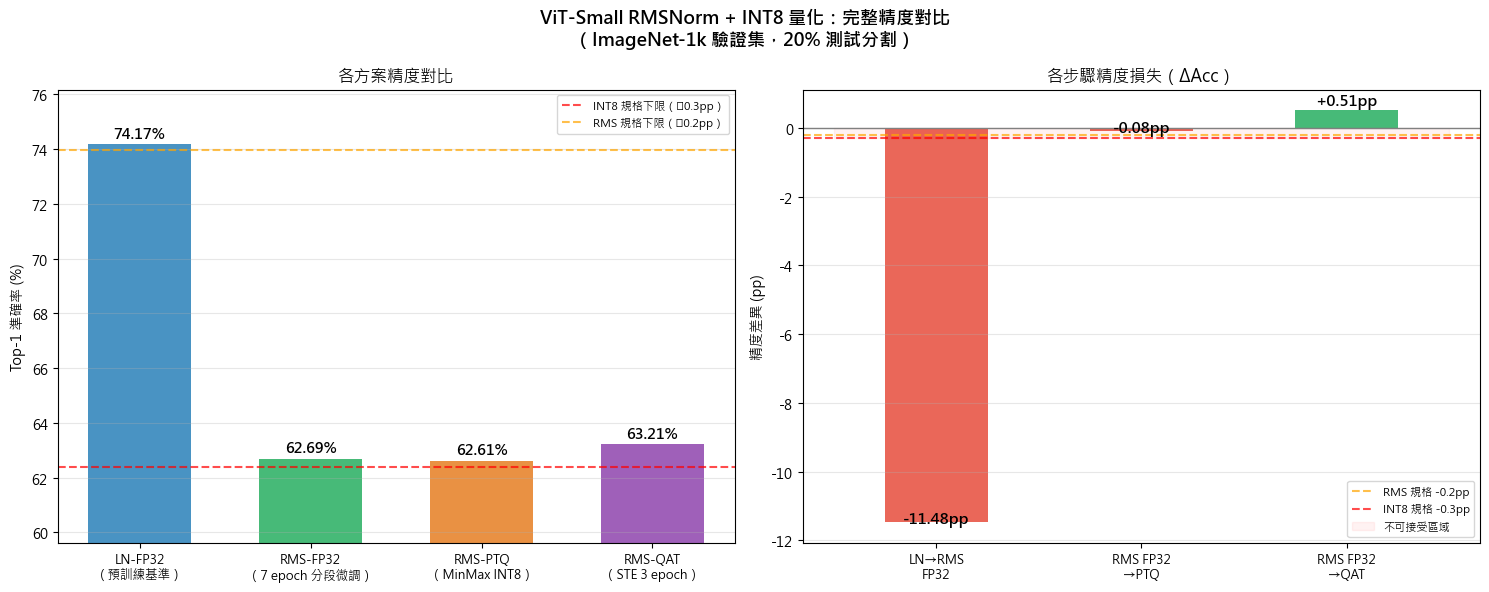

In [21]:
# ═══════════════════════════════════════════════════════════════
# Step 9A：精度對比總覽圖
# ═══════════════════════════════════════════════════════════════

results = {
    'LN-FP32\n（預訓練基準）'           : acc_ln_base,
    'RMS-FP32\n（7 epoch 分段微調）'     : acc_rms_fp32,
    'RMS-PTQ\n（MinMax INT8）'           : acc_rms_ptq,
    f'RMS-QAT\n（STE {QAT_EPOCHS} epoch）': acc_rms_qat,
}

labels = list(results.keys())
accs   = list(results.values())
colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("ViT-Small RMSNorm + INT8 量化：完整精度對比\n"
             "（ImageNet-1k 驗證集，20% 測試分割）",
             fontsize=13, fontweight='bold')

# ── 左：條狀精度圖 ──
bars = axes[0].bar(range(len(accs)), accs, color=colors, alpha=0.85, width=0.6)
for i, (bar, acc) in enumerate(zip(bars, accs)):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.1,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10.5, fontweight='bold')

y_min = min(accs) - 3
axes[0].set_ylim(y_min, max(accs) + 2)
axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Top-1 準確率 (%)')
axes[0].set_title('各方案精度對比')
axes[0].grid(True, alpha=0.3, axis='y')

# 規格書下限
axes[0].axhline(acc_rms_fp32 + SPEC_INT8_THRESHOLD,
                color='red', ls='--', alpha=0.7, label=f'INT8 規格下限（−{abs(SPEC_INT8_THRESHOLD)}pp）')
axes[0].axhline(acc_ln_base + SPEC_RMS_THRESHOLD,
                color='orange', ls='--', alpha=0.7, label=f'RMS 規格下限（−{abs(SPEC_RMS_THRESHOLD)}pp）')
axes[0].legend(fontsize=8)

# ── 右：ΔAcc 瀑布圖 ──
delta_labels = ['LN→RMS\nFP32', 'RMS FP32\n→PTQ', 'RMS FP32\n→QAT']
delta_vals   = [
    acc_rms_fp32 - acc_ln_base,   # RMSNorm 替換代價
    delta_ptq,                     # PTQ 量化代價
    delta_qat,                     # QAT 量化代價
]
d_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in delta_vals]
bars2 = axes[1].bar(range(len(delta_vals)), delta_vals, color=d_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars2, delta_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + (0.03 if v >= 0 else -0.15),
                 f'{v:+.2f}pp', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].axhline(0, color='gray', lw=1)
axes[1].axhline(SPEC_RMS_THRESHOLD, color='orange', ls='--',
                alpha=0.7, label=f'RMS 規格 {SPEC_RMS_THRESHOLD}pp')
axes[1].axhline(SPEC_INT8_THRESHOLD, color='red', ls='--',
                alpha=0.7, label=f'INT8 規格 {SPEC_INT8_THRESHOLD}pp')
axes[1].fill_between([-0.5, 2.5], SPEC_INT8_THRESHOLD, 0,
                     alpha=0.05, color='red', label='不可接受區域')
axes[1].set_xticks(range(len(delta_labels))); axes[1].set_xticklabels(delta_labels, fontsize=9)
axes[1].set_ylabel('精度差異 (pp)')
axes[1].set_title('各步驟精度損失（ΔAcc）')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("05_完整精度對比.png", dpi=120)
plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════
# Step 9B：完整結果數值表（可直接貼入報告）
# ═══════════════════════════════════════════════════════════════

print("═" * 75)
print(" ViT-Small RMSNorm + INT8 量化完整實驗報告".center(75))
print(" 規格書 v3.1 Phase 0（6.6 節）+ Phase 1（INT8）驗證".center(75))
print("═" * 75)
print()
row_fmt = "{:<28} {:>10} {:>10} {:>10} {:>10}"
print(row_fmt.format("項目", "LN-FP32", "RMS-FP32", "RMS-PTQ", "RMS-QAT"))
print("─" * 75)

rows = [
    ("CIFAR-10 Top-1 (%)",
     f"{acc_ln_base:.2f}", f"{acc_rms_fp32:.2f}",
     f"{acc_rms_ptq:.2f}", f"{acc_rms_qat:.2f}"),
    ("vs LN-FP32 ΔAcc (pp)",
     "基準",
     f"{acc_rms_fp32 - acc_ln_base:+.2f}",
     f"{acc_rms_ptq  - acc_ln_base:+.2f}",
     f"{acc_rms_qat  - acc_ln_base:+.2f}"),
    ("vs RMS-FP32 ΔAcc (pp)",
     "—", "基準",
     f"{delta_ptq:+.2f}",
     f"{delta_qat:+.2f}"),
    ("Norm 遍歷次數（硬體）", "2次", "1次", "1次", "1次"),
    ("有無 β 偏移參數", "有", "無", "無", "無"),
    ("Weight 精度", "FP32", "FP32", "INT8", "INT8(fq)"),
    ("參數量",
     f"{p_ln/1e6:.2f}M",
     f"{p_rms/1e6:.2f}M",
     f"{p_rms/1e6:.2f}M",
     f"{p_rms/1e6:.2f}M"),
]
for r in rows:
    print(row_fmt.format(*r))

print("─" * 75)
print()
print("規格書合規性驗證：")
checks = [
    ("6.6 節：RMSNorm 精度損失 < 0.2pp",
     acc_rms_fp32 - acc_ln_base, SPEC_RMS_THRESHOLD),
    ("Phase 1：PTQ INT8 精度損失 < 0.3pp",
     delta_ptq, SPEC_INT8_THRESHOLD),
    ("Phase 1：QAT INT8 精度損失 < 0.3pp",
     delta_qat, SPEC_INT8_THRESHOLD),
]
for name, delta, threshold in checks:
    status = "✅ 通過" if delta >= threshold else "❌ 未通過"
    print(f"  [{status}] {name}  → ΔAcc={delta:+.2f}pp（下限 {threshold}pp）")

print()
print("訓練策略改善效果：")
print(f"  先前（2 epoch 全層）: ~69%")
print(f"  現在（Stage A 2ep + Stage B 5ep）: {acc_rms_fp32:.2f}%")
print(f"  提升：{acc_rms_fp32 - 69:.1f}pp")
print("═" * 75)

print("\n已儲存圖表：")
for fn in ["01_資料集樣本.png", "02_RMSNorm訓練曲線.png",
           "03_PTQ_weight分佈.png", "04_QAT訓練曲線.png", "05_完整精度對比.png"]:
    print(f"  {fn}")

═══════════════════════════════════════════════════════════════════════════
                      ViT-Small RMSNorm + INT8 量化完整實驗報告                    
                  規格書 v3.1 Phase 0（6.6 節）+ Phase 1（INT8）驗證                 
═══════════════════════════════════════════════════════════════════════════

項目                              LN-FP32   RMS-FP32    RMS-PTQ    RMS-QAT
───────────────────────────────────────────────────────────────────────────
CIFAR-10 Top-1 (%)                74.17      62.69      62.61      63.21
vs LN-FP32 ΔAcc (pp)                 基準     -11.48     -11.56     -10.96
vs RMS-FP32 ΔAcc (pp)                 —         基準      -0.08      +0.51
Norm 遍歷次數（硬體）                        2次         1次         1次         1次
有無 β 偏移參數                             有          無          無          無
Weight 精度                          FP32       FP32       INT8   INT8(fq)
參數量                              22.05M     22.04M     22.04M     22.04M
───────────────────────────────────